# Hypothesis test 1

## import data 

In [3]:
library(dplyr)
library(emmeans)
library(car)
library(ggplot2)
library(tidyr)
library(tibble)
library(boot)
library(PrettyCols)
library(lmtest)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”

Attaching package: ‘boot’


The following object is masked from ‘package:car’:

    logit


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




In [5]:
fulldataAS = read.csv("/Users/emmal/Desktop/CODE/VisualSearchLLM/Analysis/AmbiguityAsSuccess.csv", stringsAsFactors = T)

In [34]:
fulldataAS = fulldataAS %>% filter(condition != "NoDistractors")

print(unique(fulldataAS$failure_type))

fulldataAS$condition <- droplevels(fulldataAS$condition)
condition_levels <- c(
  "2Among5Colour",
  "2Among5NoColour",
  "2Among5ConjRed"
)
condition_labels <- c(
  "2Among5Colour"   = "Disjunctive",
  "2Among5NoColour" = "Shape Conjunctive",
  "2Among5ConjRed"  = "Shape + Colour Conjunctive"
)
bin_labels <- c(
  "1"  = "1\n(1–4)",
  "2"  = "2\n(5–8)",
  "3"  = "3\n(9–16)",
  "4"  = "4\n(17–32)",
  "5"  = "5\n(33–64)",
  "6"  = "6\n(65–99)"
)
colours <- c(
  '2Among5Colour'    = "#9B69FF",
  '2Among5ConjRed'   = "#DFC12F",
  '2Among5NoColour'  = "#F84AC1"
)

table(fulldataAS$success)
table(fulldataAS$condition)
table(fulldataAS$bin_group)

fulldataAS$condtion = as.factor(fulldataAS$condition)
fulldataAS$bin_group = as.integer(fulldataAS$bin_group)
fulldataAS$video_filename = as.factor(fulldataAS$video_filename)
class(fulldataAS$bin_group)   
subset(fulldataAS, video_filename == "2Among5ConjRed_Bin2_Sample3.mp4", select = grep("^err_", names(fulldataAS), value = TRUE))


[1] new_generation ambiguity                     location      
Levels:  ambiguity location new_generation



 0  1 
65 43 


  2Among5Colour  2Among5ConjRed 2Among5NoColour 
             36              36              36 


 1  2  3  4  5  6 
18 18 18 18 18 18 

[1] "integer"

,err_no_distractors,err_no_target,err_wrong_manip,err_new_target_id,err_new_target_unid,err_extra_distractors,err_font_change,err_rotation,err_movement,err_enlarge_target,err_enlarge_distractors,err_target_centre,err_circular_motion,err_merging,err_id_change_before,err_id_change_after,err_vanishing
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
89,0,0,0,1,0,0,1,1,1,1,0,1,1,0,0,0,0


### descriptives 

In [35]:
print(fulldataAS %>% group_by(condition) %>% summarise(mean_success = mean(success), se = sd(success) / sqrt(n()), n = n(), confidence_interval_upper = mean(success) + 1.96 * sd(success) / sqrt(n), confidence_interval_lower = mean(success) - 1.96 * sd(success) / sqrt(n)))
print(fulldataAS %>% group_by(bin_group) %>% summarise(mean_success = mean(success), n = n(), confidence_interval_upper = mean(success) + 1.96 * sd(success) / sqrt(n), confidence_interval_lower = mean(success) - 1.96 * sd(success) / sqrt(n)))
success_per_con_bin <- fulldataAS %>%
  group_by(condition, bin_group) %>%
  summarise(
    mean_success = mean(success),
    n = n(),  
    se = sd(success) / sqrt(n),
    confidence_interval_upper = mean(success) + 1.96 * sd(success) / sqrt(n),
    confidence_interval_lower = mean(success) - 1.96 * sd(success) / sqrt(n)
  )
print(success_per_con_bin)

# A tibble: 3 × 6
  condition       mean_success     se     n confidence_interval_upper
  <fct>                  <dbl>  <dbl> <int>                     <dbl>
1 2Among5Colour          0.806 0.0669    36                     0.937
2 2Among5ConjRed         0.194 0.0669    36                     0.326
3 2Among5NoColour        0.194 0.0669    36                     0.326
# ℹ 1 more variable: confidence_interval_lower <dbl>
# A tibble: 6 × 5
  bin_group mean_success     n confidence_interval_upper confidence_interval_l…¹
      <int>        <dbl> <int>                     <dbl>                   <dbl>
1         1        0.833    18                     1.01                   0.656 
2         2        0.278    18                     0.491                  0.0649
3         3        0.389    18                     0.621                  0.157 
4         4        0.333    18                     0.557                  0.109 
5         5        0.222    18                     0.420                  0

`summarise()` has grouped output by 'condition'. You can override using the
`.groups` argument.


# A tibble: 18 × 7
# Groups:   condition [3]
   condition       bin_group mean_success     n    se confidence_interval_upper
   <fct>               <int>        <dbl> <int> <dbl>                     <dbl>
 1 2Among5Colour           1        0.833     6 0.167                     1.16 
 2 2Among5Colour           2        0.667     6 0.211                     1.08 
 3 2Among5Colour           3        0.833     6 0.167                     1.16 
 4 2Among5Colour           4        0.833     6 0.167                     1.16 
 5 2Among5Colour           5        0.667     6 0.211                     1.08 
 6 2Among5Colour           6        1         6 0                         1    
 7 2Among5ConjRed          1        0.833     6 0.167                     1.16 
 8 2Among5ConjRed          2        0.167     6 0.167                     0.493
 9 2Among5ConjRed          3        0.167     6 0.167                     0.493
10 2Among5ConjRed          4        0         6 0                         0

## Assumption testing

, ,  = 1

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             1              1               1
  1             5              5               5

, ,  = 2

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             2              5               6
  1             4              1               0

, ,  = 3

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             1              5               5
  1             5              1               1

, ,  = 4

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             1              6               5
  1             5              0               1

, ,  = 5

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             2              6               6
  1             4              0               0

, ,  = 6

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             0              6               6
  1             6              0               0


Model :
success ~ condition * bin_group


there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
condition,28.052071,2,2.301395
bin_group,1.705029,1,1.305767
condition:bin_group,23.173861,2,2.194066


,GVIF,Df,GVIF^(1/(2*Df))
condition,1.342005,2,1.076313
bin_group,1.342005,1,1.158450


,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
68,2.686552,0.04975135,0.188764590
75,0.769492,0.13206623,0.009143184
90,0.769492,0.13206623,0.009143184
91,2.547465,0.07372433,0.197762598


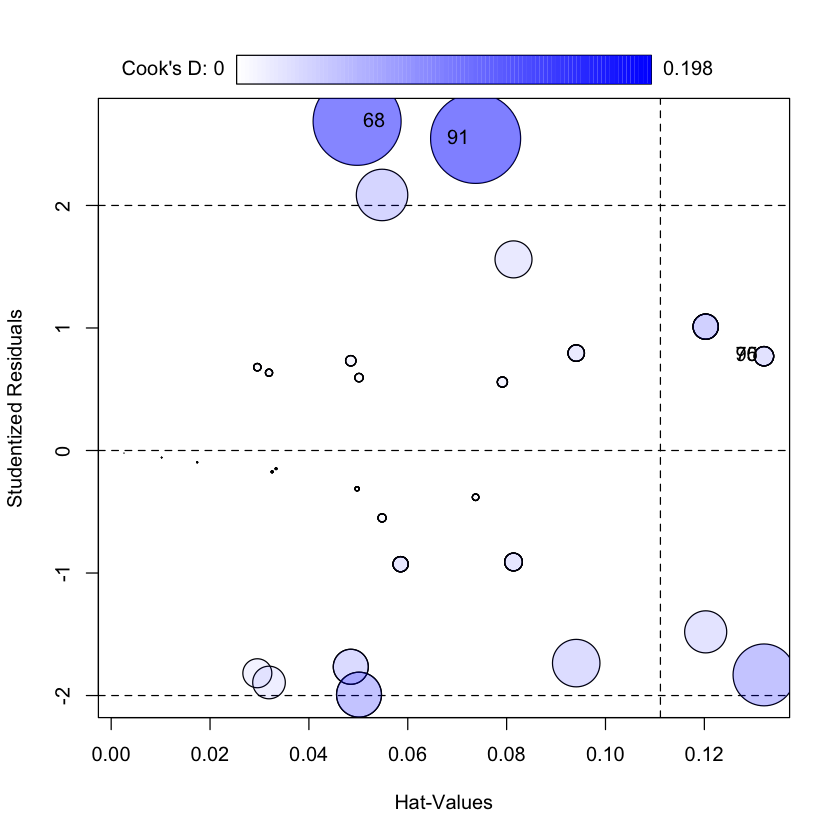

,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
5,1.092513,0.06870003,0.01516279
8,-2.365752,0.02556522,0.08661578
9,1.092513,0.06870003,0.01516279
10,-2.620662,0.02266135,0.13522039


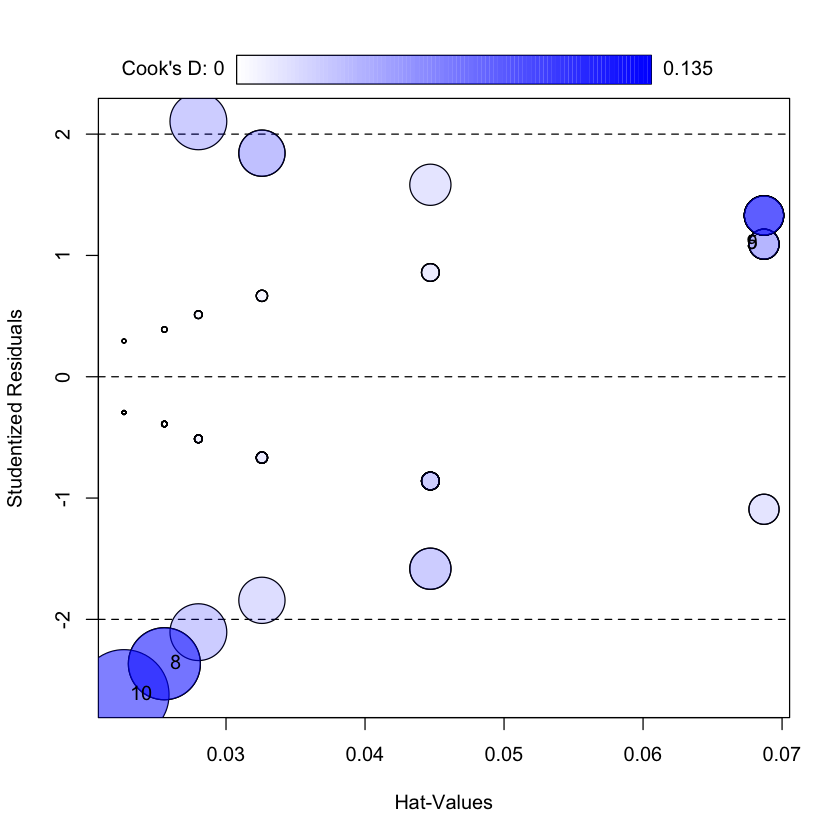

In [36]:
modelRQ1 = glm(success ~condition*bin_group, data = fulldataAS, family = binomial(link = "logit"))
smallmodelRQ1 = glm(success ~ condition + bin_group, data   = fulldataAS, family = binomial(link = "logit"))
# separation (OK)
table(fulldataAS$success, fulldataAS$condition, fulldataAS$bin_group)
# multicollinearity of IVs - < 10 (likley ok; GVIF for df= 1 ok, ADjusted GVIF^(1/2*df) < sqrt(threshold))
alias(modelRQ1)
car::vif(modelRQ1)
car::vif(smallmodelRQ1)
# linearity of log odds - only for continuous 
# DV is binominal
# uniqueness of observations (for now) assumed
# Sample size at least 10 per term = not given but cannot change (success = 28; fail = 80) <- given DF = 17 issue partially 
# outliers = cooks distance is OK
influencePlot(modelRQ1, id=T)
influencePlot(smallmodelRQ1, id = T)

## Run model(S)

### visualization

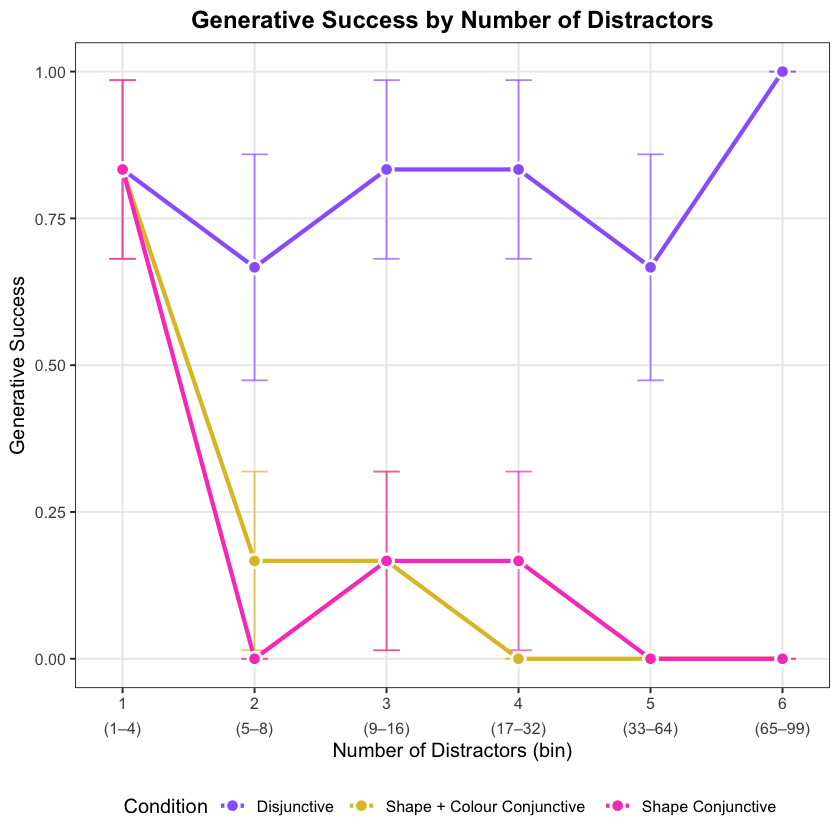

In [37]:
groupeddataAS = read.csv("/Users/emmal/Desktop/CODE/VisualSearchLLM/Analysis/generative_success_AS.csv", stringsAsFactors = T)
groupeddataAS = groupeddataAS %>% filter(condition != "NoDistractors")

ggplot(groupeddataAS, 
       aes(x      = bin, 
           y      = generative_success,
           colour = condition)) +
  geom_errorbar(aes(ymin = generative_success - se_success,
                    ymax = generative_success + se_success),
                width     = 0.2,
                linewidth = 0.5,
                alpha     = 0.7) +
  geom_line(linewidth = 1.2) +
  geom_point(size   = 3,
             shape  = 21,
             aes(fill = condition),
             colour = "white",
             stroke = 1.2) +
  scale_colour_manual(
    values = colours,
    labels = condition_labels
  ) +
  scale_fill_manual(
    values = colours,
    labels = condition_labels
  ) +
  scale_x_continuous(
    breaks = 1:6,
    labels = bin_labels
  ) +
  labs(x      = "Number of Distractors (bin)",
       y      = "Generative Success",
       colour = "Condition",
       fill   = "Condition",
       title = "Generative Success by Number of Distractors") +
  theme_minimal(base_size = 13) +
  theme_bw(base_size = 12)+
  theme(
    legend.position  = "bottom",
    strip.text       = element_text(face = "bold", size = 12),
    panel.grid.minor = element_blank(),
    panel.spacing    = unit(1.5, "lines"),
    plot.title       = element_text(face = "bold", hjust = 0.5),
    axis.text.x      = element_text(lineheight = 1.3)
  )

In [38]:
## alt consideration of the factor version of bin group
fullmodelRQ1_factor = glm(success ~ condition*as.factor(bin_group), data = fulldataAS, family = binomial(link = "logit"))
anova(fullmodelRQ1_factor, modelRQ1, test = "Chisq")
# factor version is not significantly better than the model with bin group as numeric, so we can keep the simpler model (with bin group as numeric)

# drop1(modelRQ1, test = "Chisq")
anova(modelRQ1, smallmodelRQ1, test = "Chisq")
## as significant diff of models; keep interaction model

summary(modelRQ1)
print(pchisq((modelRQ1$null.deviance - modelRQ1$deviance), (modelRQ1$df.null - modelRQ1$df.residual), lower.tail = FALSE))
cat("\n  delta x^2 = " , round((modelRQ1$null.deviance - modelRQ1$deviance), digits = 3) , "\n")
cat("\n  Odds ratios (exp(coef)):\n")
print(round(exp(cbind(OR = coef(modelRQ1), confint(modelRQ1))), 3))


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,90,63.93695,NA,NA,NA
2,102,77.02761,-12,-13.09065,0.3624861


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,102,77.02761,NA,NA,NA
2,104,93.38180,-2,-16.35419,0.0002810164



Call:
glm(formula = success ~ condition * bin_group, family = binomial(link = "logit"), 
    data = fulldataAS)

Coefficients:
                                   Estimate Std. Error z value Pr(>|z|)  
(Intercept)                          0.9042     0.9139   0.989   0.3225  
condition2Among5ConjRed              2.1512     1.7536   1.227   0.2199  
condition2Among5NoColour             0.7858     1.4340   0.548   0.5837  
bin_group                            0.1538     0.2509   0.613   0.5399  
condition2Among5ConjRed:bin_group   -2.0473     0.8006  -2.557   0.0106 *
condition2Among5NoColour:bin_group  -1.3321     0.5393  -2.470   0.0135 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 145.207  on 107  degrees of freedom
Residual deviance:  77.028  on 102  degrees of freedom
AIC: 89.028

Number of Fisher Scoring iterations: 7


[1] 2.450984e-13

  delta x^2 =  68.179 

  Odds ratios (exp(coef)):


Waiting for profiling to be done...



                                      OR 2.5 %  97.5 %
(Intercept)                        2.470 0.444  17.630
condition2Among5ConjRed            8.595 0.354 478.056
condition2Among5NoColour           2.194 0.134  42.963
bin_group                          1.166 0.716   1.970
condition2Among5ConjRed:bin_group  0.129 0.017   0.455
condition2Among5NoColour:bin_group 0.264 0.074   0.664


## post hock testing

In [39]:
# post-hoc tests for bin effects within each condition (Each row tests H₀: slope = 0)
trends_RQ1 <- emtrends(modelRQ1, 
                       specs = ~ condition, 
                       var   = "bin_group")
summary(trends_RQ1, infer = c(TRUE, TRUE))
# => set sixe effect in condition ?
# paiwise contrasts for slope diffrerences across conditions 
trends_RQ1_pairs <- emtrends(modelRQ1, pairwise ~ condition, var = "bin_group")
summary(trends_RQ1_pairs$contrasts, infer = c(TRUE, TRUE))
# => conditions differ in steepness of slope ? 
## results show no significant differences in slope across conditions, but a significant slope in the NOColour & Conjunctive condition (and non-significant slope in simple colour condition).



,condition,bin_group.trend,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2Among5Colour,0.1537726,0.2508961,Inf,-0.3379747,0.6455200,0.6128937,0.53994666
2,2Among5ConjRed,-1.8935712,0.7602935,Inf,-3.3837190,-0.4034233,-2.4905792,0.01275351
3,2Among5NoColour,-1.1782806,0.4774185,Inf,-2.1140035,-0.2425576,-2.4680248,0.01358609


,contrast,estimate,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2Among5Colour - 2Among5ConjRed,2.0473438,0.8006217,Inf,0.17092634,3.923761,2.5571926,0.02844921
2,2Among5Colour - 2Among5NoColour,1.3320532,0.5393304,Inf,0.06802432,2.596082,2.4698280,0.03603824
3,2Among5ConjRed - 2Among5NoColour,-0.7152906,0.8977609,Inf,-2.81937325,1.388792,-0.7967496,0.70502416


In [40]:
# Failure types 
print(table(fulldataAS$failure_type, useNA = "ifany"))
failures_df <- fulldataAS %>%
  filter(success == 0, !is.na(failure_type))  # exclude bin 0 if that = no distractors

failure_ct <- table(failures_df$failure_type, failures_df$condition)
print(failure_ct)

# No-distractor condition — reported descriptively
nodist_failures <- fulldataAS %>%
  filter(success == 0, failure_type == "No Distractors")

cat("\nNo-distractor failures (descriptive only):\n")
print(table(nodist_failures$condition))

# Check expected cell counts
expected <- chisq.test(failure_ct)$expected
cat(sprintf("\nMinimum expected count: %.2f\n", min(expected)))

# Choose test accordingly
if (min(expected) >= 5) {
  cat("Using Pearson chi-square\n")
  print(chisq.test(failure_ct))
} else {
  cat("Using Fisher-Freeman-Halton exact test\n")
  print(fisher.test(failure_ct, simulate.p.value = TRUE, B = 10000))
}



                    ambiguity       location new_generation 
            28             15              2             63 


                
                 2Among5Colour 2Among5ConjRed 2Among5NoColour
                             0              0               0
  ambiguity                  0              0               0
  location                   0              1               1
  new_generation             7             28              28

No-distractor failures (descriptive only):

  2Among5Colour  2Among5ConjRed 2Among5NoColour 
              0               0               0 


Warning message in chisq.test(failure_ct):
“Chi-squared approximation may be incorrect”



Minimum expected count: 0.00
Using Fisher-Freeman-Halton exact test

	Fisher's Exact Test for Count Data with simulated p-value (based on
	10000 replicates)

data:  failure_ct
p-value = 1
alternative hypothesis: two.sided



### visualisation

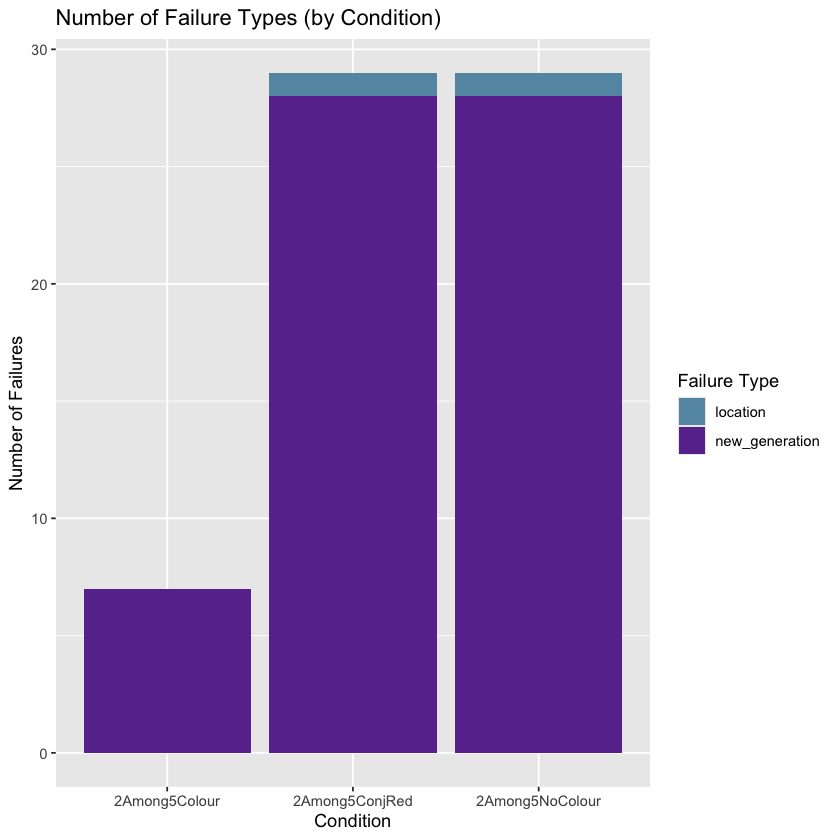

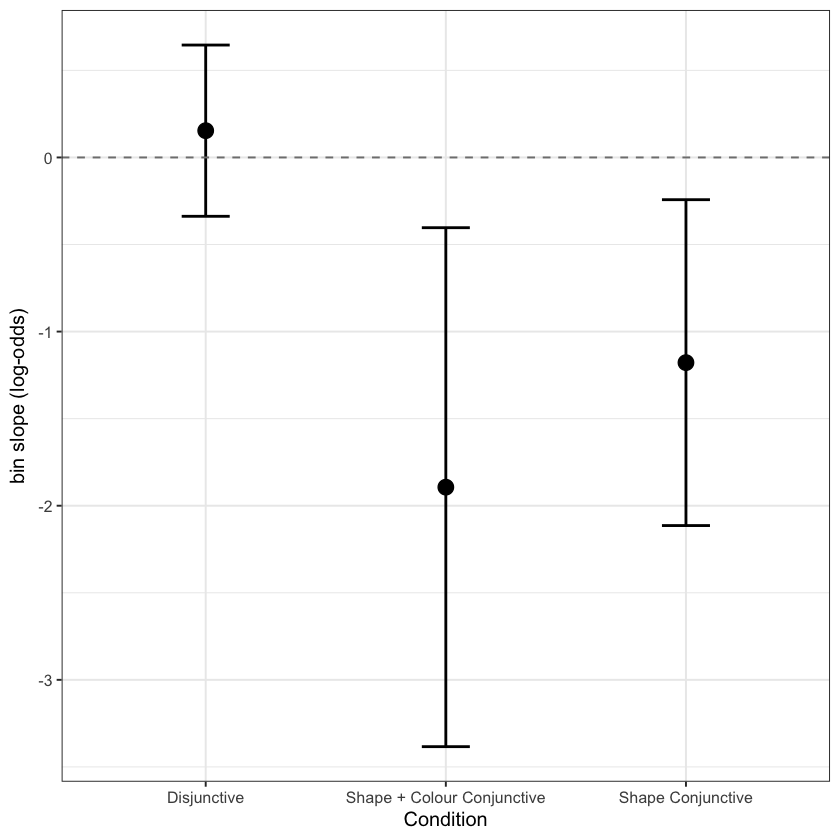

In [41]:

ggplot(failures_df, aes(x = condition, fill = failure_type)) +
  geom_bar(position = "stack") +
  scale_fill_pretty_d("Bold" ) +
  labs(title = "Number of Failure Types (by Condition)",
       x = "Condition",
       y = "Number of Failures",
       fill = "Failure Type") +
  theme_gray() 


#  means at each bin_group × condition
trends_RQ1_df <- summary(trends_RQ1, infer = c(TRUE, TRUE)) %>%
  as.data.frame()

ggplot(trends_RQ1_df, aes(x = condition, y = bin_group.trend)) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = asymp.LCL, ymax = asymp.UCL), 
                width = 0.2, linewidth = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey50") +
  scale_x_discrete(labels = condition_labels) +
  labs(
    x        = "Condition",
    y        = "bin slope (log-odds)",
  ) +
  theme_bw(base_size = 12) 


ggsave("fig_slopes_per_condition.png", width = 6, height = 5, dpi = 150)

## Firths version

### assumptions

In [42]:
# issue 1 somse cells will show full separation
# high separation for some points issue 
# Events per variable (EPV) — rule of thumb >= 10 per parameter , not iven hence penalised regression (Firth's logistic regression)

### model

In [43]:
fulldataAS$bin_group = as.integer(fulldataAS$bin_group)
library(logistf)
modelRQ1_firth = logistf(success ~ condition*bin_group, data = fulldataAS)
summary(modelRQ1_firth)

Registered S3 method overwritten by 'lme4':
  method           from
  na.action.merMod car 



logistf(formula = success ~ condition * bin_group, data = fulldataAS)

Model fitted by Penalized ML
Coefficients:
                                         coef  se(coef) lower 0.95 upper 0.95
(Intercept)                         0.8586209 0.8616947 -0.7763031  2.7178382
condition2Among5ConjRed             1.5387559 1.4825357 -1.3504380  5.0336681
condition2Among5NoColour            0.5122988 1.3002682 -2.0956862  3.2539746
bin_group                           0.1371050 0.2340760 -0.3239382  0.6299510
condition2Among5ConjRed:bin_group  -1.6319302 0.6120148 -3.3516810 -0.5707637
condition2Among5NoColour:bin_group -1.1201698 0.4547039 -2.2446269 -0.2954823
                                        Chisq            p method
(Intercept)                         1.0326189 0.3095443490      2
condition2Among5ConjRed             1.0486259 0.3058237633      2
condition2Among5NoColour            0.1490691 0.6994265200      2
bin_group                           0.3410417 0.5592285275      2
condition2

In [44]:
#odds ratio/ CIs
data.frame(
  OR    = exp(coef(modelRQ1_firth)),
  CI_lo = exp(modelRQ1_firth$ci.lower),
  CI_hi = exp(modelRQ1_firth$ci.upper),
  p     = modelRQ1_firth$prob
) %>%
  round(3) %>%
  print()

                                      OR CI_lo   CI_hi     p
(Intercept)                        2.360 0.460  15.148 0.310
condition2Among5ConjRed            4.659 0.259 153.495 0.306
condition2Among5NoColour           1.669 0.123  25.893 0.699
bin_group                          1.147 0.723   1.878 0.559
condition2Among5ConjRed:bin_group  0.196 0.035   0.565 0.001
condition2Among5NoColour:bin_group 0.326 0.106   0.744 0.006


In [45]:
# Compare to standard logistic regression results
comparison_ModelsRQ1 = data.frame(parameter = names(coef(modelRQ1_firth)),
                                    glm_coef = round(coef(modelRQ1), 3),
                                    firth_coef = round(coef(modelRQ1_firth), 3),
                                    difference = round(coef(modelRQ1) - coef(modelRQ1_firth), 3))  
print(comparison_ModelsRQ1)

                                                            parameter glm_coef
(Intercept)                                               (Intercept)    0.904
condition2Among5ConjRed                       condition2Among5ConjRed    2.151
condition2Among5NoColour                     condition2Among5NoColour    0.786
bin_group                                                   bin_group    0.154
condition2Among5ConjRed:bin_group   condition2Among5ConjRed:bin_group   -2.047
condition2Among5NoColour:bin_group condition2Among5NoColour:bin_group   -1.332
                                   firth_coef difference
(Intercept)                             0.859      0.046
condition2Among5ConjRed                 1.539      0.612
condition2Among5NoColour                0.512      0.274
bin_group                               0.137      0.017
condition2Among5ConjRed:bin_group      -1.632     -0.415
condition2Among5NoColour:bin_group     -1.120     -0.212


# Hypothesis 2 

## import data 

In [46]:
humandata = read.csv("/Users/emmal/Desktop/CODE/VisualSearchLLM/Analysis/HumanData.csv", stringsAsFactors = T)
print(colnames(humandata))
table(humandata$shape_type)
hummandata = humandata %>% filter(shape_type != "5")
table(humandata$colour_type)
table(humandata$accuracy)
table(humandata$bin_group)


 [1] "PID"              "trial"            "response"         "rt"              
 [5] "accuracy"         "display"          "filename"         "shape_type"      
 [9] "colour_type"      "target_color"     "distractor_color" "quadrant"        
[13] "num_distractors"  "answer"           "distractor_bin"   "bin_group"       



   2    5 
2160 2160 


  2Among5Colour  2Among5ConjRed 2Among5NoColour 
           1440            1440            1440 


   0    1 
1005 3315 


  1   2   3   4   5   6 
720 720 720 720 720 720 

### test for colour/ identity effects as of coundernbalancing = gaps 

In [47]:
chisq.test(table(humandata$shape_type, humandata$accuracy))
chisq.test(table(humandata$target_color, humandata$accuracy))
chisq.test(table(humandata$distractor_color, humandata$accuracy))

# not significant target and shape effects, distractor may be confounded by search condition hence I choose to proceed with the full data set to omit issues with the missing data otherwise



	Pearson's Chi-squared test with Yates' continuity correction

data:  table(humandata$shape_type, humandata$accuracy)
X-squared = 0.18672, df = 1, p-value = 0.6657



	Pearson's Chi-squared test

data:  table(humandata$target_color, humandata$accuracy)
X-squared = 4.3024, df = 2, p-value = 0.1163



	Pearson's Chi-squared test

data:  table(humandata$distractor_color, humandata$accuracy)
X-squared = 22.041, df = 2, p-value = 1.636e-05


## descriptive

In [48]:
generative_veo_success_AS = read.csv("/Users/emmal/Desktop/CODE/VisualSearchLLM/Analysis/generative_success_AS.csv", stringsAsFactors = T)
generative_veo_success_AS %>% filter(condition != "NoDistractors")
generative_veo_success_AS$condition <- droplevels(generative_veo_success_AS$condition)
Veo_summary <- generative_veo_success_AS %>% filter(condition != "NoDistractors") %>%
  rename(
    bin_group    = bin,
    mean_acc_veo = generative_success,
    se_veo       = se_success
  ) %>%
  mutate(
    condition = as.character(condition),
    bin_group = as.integer(bin_group)
  ) %>%
  select(condition, bin_group, mean_acc_veo, se_veo, ci_lower, ci_upper)

Human_summary <- humandata %>%
  group_by(colour_type, bin_group) %>%
  summarise(
    mean_acc_human = mean(accuracy, na.rm = TRUE),
    n              = n(),
    se_human       = sqrt(mean_acc_human * (1 - mean_acc_human) / n),
    .groups        = "drop"
  ) %>%
  rename(condition = colour_type) %>%
  mutate(
    condition = as.character(condition),
    bin_group = as.integer(bin_group)
  ) %>%
  select(condition, bin_group, mean_acc_human, se_human)

combined_wide <- Veo_summary %>%
  full_join(Human_summary, by = c("condition", "bin_group"))

print(head(combined_wide))

condition,bin,generative_success,n_success,n_total,se_success,ci_lower,ci_upper
<fct>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
2Among5Colour,1,0.8333333,5,6,0.1521452,0.5351288,1.1315378
2Among5Colour,2,0.6666667,4,6,0.1924501,0.2894645,1.0438688
2Among5Colour,3,0.8333333,5,6,0.1521452,0.5351288,1.1315378
2Among5Colour,4,0.8333333,5,6,0.1521452,0.5351288,1.1315378
2Among5Colour,5,0.6666667,4,6,0.1924501,0.2894645,1.0438688
2Among5Colour,6,1.0000000,6,6,0.0000000,1.0000000,1.0000000
2Among5ConjRed,1,0.8333333,5,6,0.1521452,0.5351288,1.1315378
2Among5ConjRed,2,0.1666667,1,6,0.1521452,-0.1315378,0.4648712
2Among5ConjRed,3,0.1666667,1,6,0.1521452,-0.1315378,0.4648712


      condition bin_group mean_acc_veo    se_veo  ci_lower ci_upper
1 2Among5Colour         1    0.8333333 0.1521452 0.5351288 1.131538
2 2Among5Colour         2    0.6666667 0.1924501 0.2894645 1.043869
3 2Among5Colour         3    0.8333333 0.1521452 0.5351288 1.131538
4 2Among5Colour         4    0.8333333 0.1521452 0.5351288 1.131538
5 2Among5Colour         5    0.6666667 0.1924501 0.2894645 1.043869
6 2Among5Colour         6    1.0000000 0.0000000 1.0000000 1.000000
  mean_acc_human    se_human
1      0.9833333 0.008263597
2      0.9666667 0.011587030
3      0.9750000 0.010077822
4      0.9708333 0.010862008
5      0.9833333 0.008263597
6      1.0000000 0.000000000


### plotting

,condition,bin_group,se_veo,ci_lower,ci_upper,se_human,agent,mean_acc,se
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
1,2Among5Colour,1,0.1521452,0.5351288,1.131538,0.008263597,Veo,0.8333333,0.1521452
2,2Among5Colour,2,0.1924501,0.2894645,1.043869,0.011587030,Veo,0.6666667,0.1924501
3,2Among5Colour,3,0.1521452,0.5351288,1.131538,0.010077822,Veo,0.8333333,0.1521452
4,2Among5Colour,4,0.1521452,0.5351288,1.131538,0.010862008,Veo,0.8333333,0.1521452
5,2Among5Colour,5,0.1924501,0.2894645,1.043869,0.008263597,Veo,0.6666667,0.1924501
6,2Among5Colour,6,0.0000000,1.0000000,1.000000,0.000000000,Veo,1.0000000,0.0000000



  2Among5Colour  2Among5ConjRed 2Among5NoColour 
             12              12              12 

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


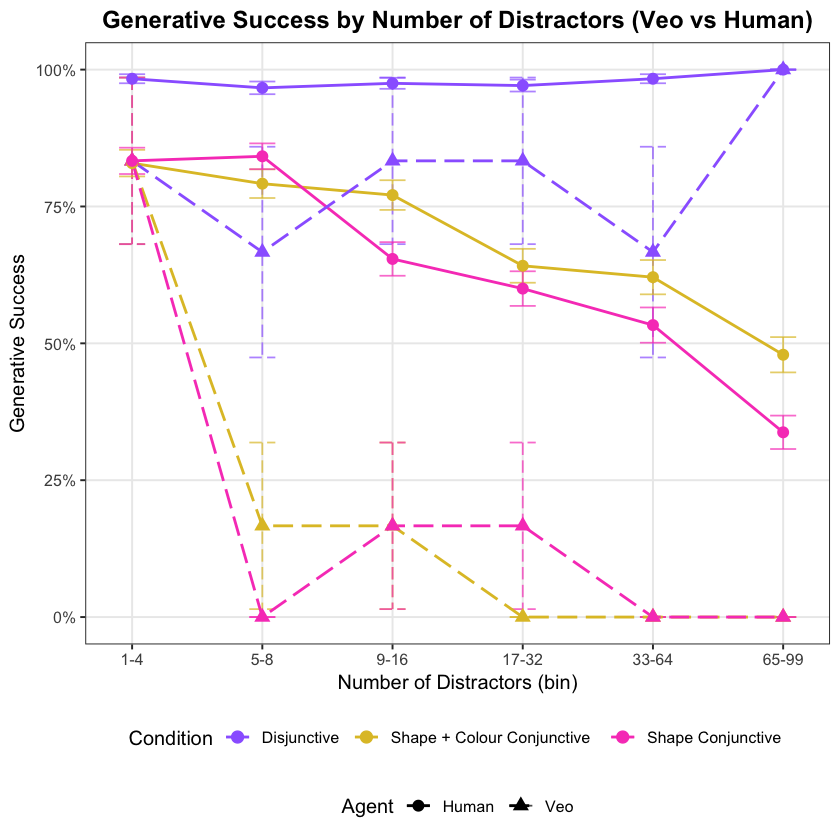

In [49]:
combined_long <- combined_wide %>%
  gather(key = "agent", value = "mean_acc", mean_acc_veo, mean_acc_human) %>%
  mutate(
    se    = ifelse(agent == "mean_acc_veo", se_veo, se_human),
    agent = ifelse(agent == "mean_acc_veo", "Veo", "Human")
  )
  head(combined_long)
table(combined_long$condition)
ggplot(combined_long, 
       aes(x        = bin_group, 
           y        = mean_acc,
           colour   = condition,
           linetype = agent,
           shape = agent,
           group    = interaction(condition, agent))) +
  geom_errorbar(aes(ymin = mean_acc - se,
                    ymax = mean_acc + se),
                width     = 0.2,
                linewidth = 0.5,
                alpha     = 0.7) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 3) +
  scale_colour_manual(
    values = colours,
    labels = condition_labels
  ) +
  scale_fill_manual(
    values = colours,
    labels = condition_labels
  ) +
  scale_linetype_manual(
  name   = "Agent",
  values = c("Human" = "solid", "Veo" = "longdash"),
  labels = c("Human", "Veo")
) +
scale_shape_manual(
  name   = "Agent",
  values = c("Human" = 16, "Veo" = 17),
  labels = c("Human", "Veo")
) +
guides(
  colour   = guide_legend(title = "Condition"),
  linetype = guide_legend(title = "Agent"),
  shape    = guide_legend(title = "Agent")
) +
  scale_x_continuous(
    breaks = 1:6,
    labels = c("1-4", "5-8", "9-16", "17-32", "33-64", "65-99")
  ) +
  scale_y_continuous(
    labels = scales::percent_format(),
    limits = c(0, 1)
  ) +
  labs(
    x        = "Number of Distractors (bin)",
    y        = "Generative Success",
    colour   = "Condition",
    linetype = "Agent",
    title = "Generative Success by Number of Distractors (Veo vs Human)"
  ) +
  theme_bw(base_size = 12) +
  theme(
    legend.position  = "bottom",
    legend.box       = "vertical",
    panel.grid.minor = element_blank(),
    plot.title       = element_text(face = "bold", hjust = 0.5),
    axis.text.x      = element_text(lineheight = 1.3)
  )


## by modelling (agent as a fixed effect)

In [75]:
humanAndVeo = bind_rows(fulldataAS %>% 
    select(success, condition, bin_group) %>% 
    mutate(agent = "Veo"),
    humandata %>% select(accuracy, colour_type, bin_group) %>% 
    rename(success = accuracy, condition = colour_type) %>%
    mutate(agent = "Human")
) %>%
  mutate(
    agent     = factor(agent, levels = c("Human", "Veo")),  # Human as reference
    condition = as.character(condition),
    condition = factor(condition),
    bin_group = as.integer(bin_group)
  )
table(humanAndVeo$agent, humanAndVeo$condition, useNA = "ifany")

       
        2Among5Colour 2Among5ConjRed 2Among5NoColour
  Human          1440           1440            1440
  Veo              36             36              36

### test assumptions


, ,  = 1

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             5             42              41
  1           241            204             205

, ,  = 2

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0            10             55              44
  1           236            191             202

, ,  = 3

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             7             60              88
  1           239            186             158

, ,  = 4

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             8             92             101
  1           238            154             145

, ,  = 5

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             6             97             118
  1           240            149             128

, ,  = 6

   
    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0             0            131             165
  1           246            115              81


Model :
success ~ agent * condition * bin_group


there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
agent,11.850819,1,3.442502
condition,34.619215,2,2.425657
bin_group,21.548849,1,4.642074
agent:condition,67.968948,2,2.871294
agent:bin_group,7.895743,1,2.809936
condition:bin_group,182.734936,2,3.676676
agent:condition:bin_group,43.787586,2,2.572396


,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
68,2.6865521,0.049751423,0.094382441
75,0.7694737,0.131994531,0.004568370
90,0.7694737,0.131994531,0.004568370
91,2.5474252,0.073713469,0.098863456
2146,-2.9255102,0.001253653,0.007139359
2214,-2.9255102,0.001253653,0.007139359



Call:
glm(formula = success ~ agent * condition * bin_group, family = binomial(link = "logit"), 
    data = humanAndVeo)

Coefficients:
                                            Estimate Std. Error z value
(Intercept)                                  3.26652    0.38634   8.455
agentVeo                                    -2.36236    0.99224  -2.381
condition2Among5ConjRed                     -1.23999    0.41452  -2.991
condition2Among5NoColour                    -1.01466    0.41512  -2.444
bin_group                                    0.19109    0.11342   1.685
agentVeo:condition2Among5ConjRed             3.39120    1.80042   1.884
agentVeo:condition2Among5NoColour            1.80046    1.49291   1.206
agentVeo:bin_group                          -0.03732    0.27534  -0.136
condition2Among5ConjRed:bin_group           -0.52563    0.11895  -4.419
condition2Among5NoColour:bin_group          -0.65505    0.11915  -5.498
agentVeo:condition2Among5ConjRed:bin_group  -1.52171    0.80807  -1.883

[1] "integer"

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4416,3758.290,NA,NA,NA
2,4392,3719.425,24,38.86417,0.02821889


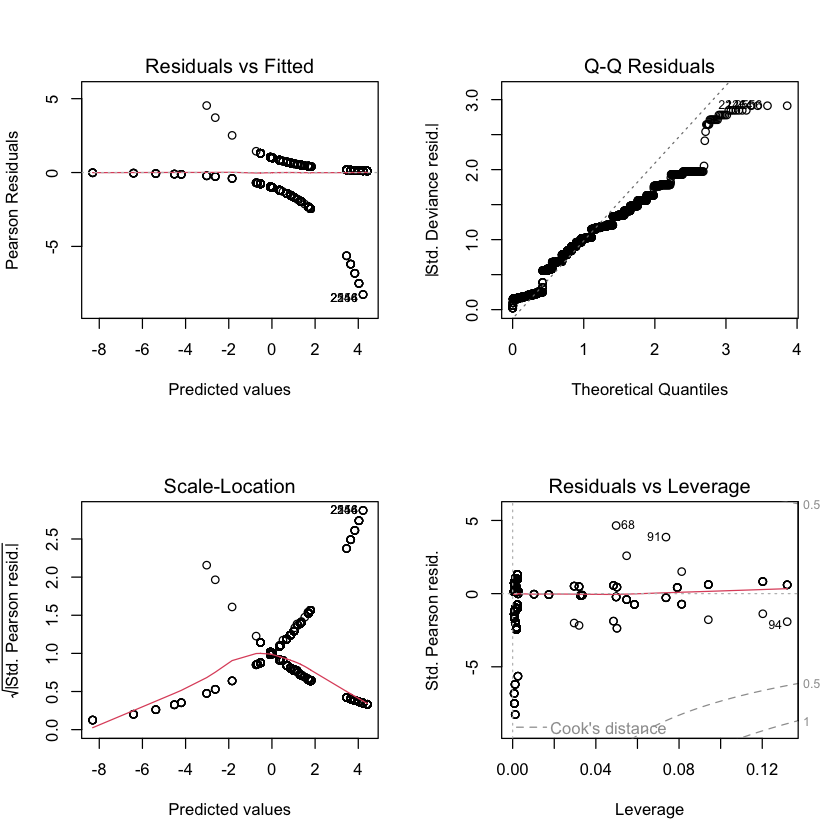

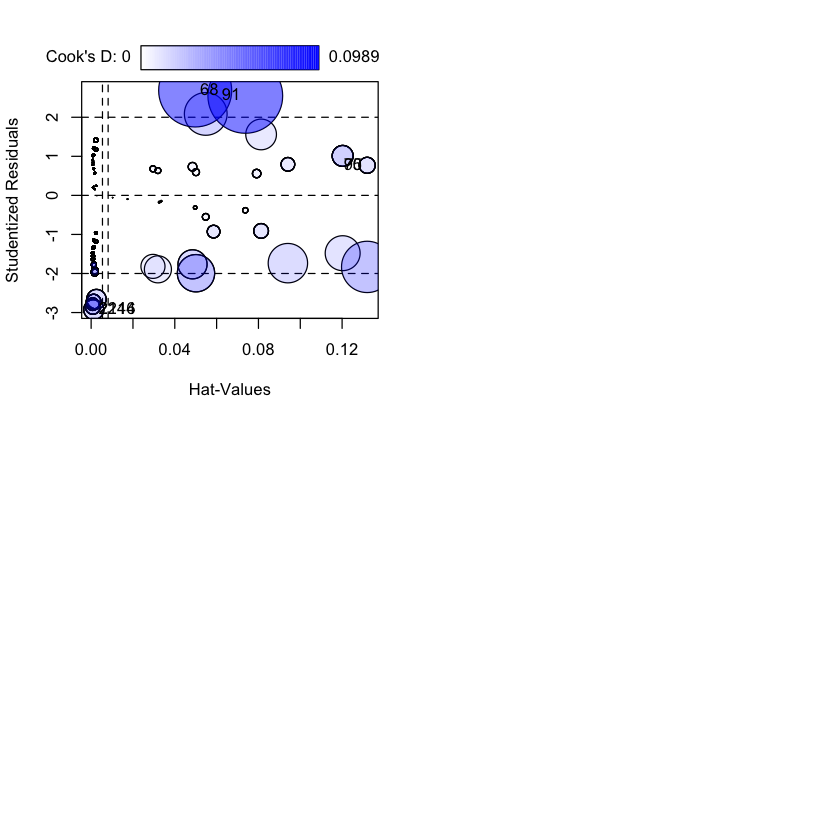

In [ ]:
model_RQ2 = glm(success ~ agent*condition*bin_group, data = humanAndVeo, family = binomial(link = "logit"))
# assumption test
# separation (OK)
table(humanAndVeo$success, humanAndVeo$condition, humanAndVeo$bin_group)
# multicollinearity of IVs - VIOLATED ==DISCUSS WHAT TO DO !! 
alias(model_RQ2)
car::vif(model_RQ2)
# linearity of log odds - only for continuous 
# DV is binominal
# uniqueness of observations (for now) assumed
# Sample size at least 10 per term = not given but cannot change (success = 28; fail = 80) <- given DF = 17 issue partially 
# outliers = cooks distance is OK
par(mfrow = c(2,2))
plot(model_RQ2)
influencePlot(model_RQ2, id=T)
# run model
summary(model_RQ2)
# ? as collapesd the individual condition/ bin varables not ineterpretable? 
# Need to consider how to report 

In [85]:
## Test alt shapes 
class(humanAndVeo$bin_group)
model_factor <- glm(success ~ agent * condition * factor(bin_group),
                    data = humanAndVeo, family = binomial)
anova(model_RQ2, model_factor, test = "LRT")
model_quad <- glm(success ~ agent * condition * (bin_group + I(bin_group^2)),
                  data = humanAndVeo, family = binomial)
anova(model_RQ2, model_quad, test = "LRT")
anova(model_quad, model_factor, test = "LRT")


print(model_factor)
print(model_quad)

[1] "integer"

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4416,3758.290,NA,NA,NA
2,4392,3719.425,24,38.86417,0.02821889


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4416,3758.290,NA,NA,NA
2,4410,3747.818,6,10.47188,0.1061357


,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4410,3747.818,NA,NA,NA
2,4392,3719.425,18,28.39229,0.05633091



Call:  glm(formula = success ~ agent * condition * factor(bin_group), 
    family = binomial, data = humanAndVeo)

Coefficients:
                                         (Intercept)  
                                           4.078e+00  
                                            agentVeo  
                                          -2.468e+00  
                             condition2Among5ConjRed  
                                          -2.498e+00  
                            condition2Among5NoColour  
                                          -2.468e+00  
                                  factor(bin_group)2  
                                          -7.102e-01  
                                  factor(bin_group)3  
                                          -4.140e-01  
                                  factor(bin_group)4  
                                          -5.724e-01  
                                  factor(bin_group)5  
                                          -1.

In [18]:
# test smaller model alternative
model_n3way_RQ2 = glm(success ~ agent * condition + 
                        agent * bin_group + 
                        condition * bin_group,
          family = binomial, data = humanAndVeo)

summary(model_n3way_RQ2)
# AIC increases; hence stick with other model



Call:
glm(formula = success ~ agent * condition + agent * bin_group + 
    condition * bin_group, family = binomial, data = humanAndVeo)

Coefficients:
                                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)                          3.0527     0.3626   8.419  < 2e-16 ***
agentVeo                            -0.9243     0.8507  -1.086   0.2773    
condition2Among5ConjRed             -1.0050     0.3907  -2.572   0.0101 *  
condition2Among5NoColour            -0.7939     0.3915  -2.028   0.0426 *  
bin_group                            0.2653     0.1113   2.385   0.0171 *  
agentVeo:condition2Among5ConjRed    -0.2632     0.7200  -0.366   0.7147    
agentVeo:condition2Among5NoColour   -0.1877     0.7365  -0.255   0.7988    
agentVeo:bin_group                  -0.4579     0.1926  -2.377   0.0174 *  
condition2Among5ConjRed:bin_group   -0.6053     0.1163  -5.204 1.95e-07 ***
condition2Among5NoColour:bin_group  -0.7311     0.1166  -6.271 3.59e-10 ***
---
Signif.

In [29]:
# spearman rank correlatoin
performance_vectors <- humanAndVeo %>%
  group_by(agent, condition, bin_group) %>%
  summarise(
    mean_acc = mean(success, na.rm = TRUE),
    .groups  = "drop"
  ) %>%
  group_by(agent) %>%
  mutate(mean_acc_centred = mean_acc - mean(mean_acc, na.rm = TRUE)) %>%
  ungroup()
# mean centering 
vectors_wide <- performance_vectors %>%
  select(condition, bin_group, agent, mean_acc_centred) %>%
  pivot_wider(names_from  = agent,
              values_from = mean_acc_centred) %>%
  arrange(condition, bin_group)

spearman_res <- cor.test(
  vectors_wide$Veo,
  vectors_wide$Human,
  method = "spearman",
)
print(spearman_res)
# bootstrap confidence intervals for spearman correlation
set.seed(23)
boot_fn <- function(data, idx) {
  cor(data[idx, "Veo"], data[idx, "Human"], method = "spearman")
}

boot_res <- boot(
  data      = as.data.frame(vectors_wide),
  statistic = boot_fn,
  R         = 1000
)

boot_ci <- boot.ci(boot_res, type = "perc", conf = 0.95)

cat(sprintf(
  "\nSpearman ρ = %.3f  (p = %.4f)\n95%% bootstrap CI [%.3f, %.3f]\n",
  spearman_res$estimate,
  spearman_res$p.value,
  boot_ci$percent[4],
  boot_ci$percent[5]
))

# triallevel bootstraps
boot_fn_trials <- function(data, idx) {
  # Resample trials, recompute cell means, then correlate
  resampled <- data[idx, ]
  
  cell_means <- resampled %>%
    group_by(agent, condition, bin_group) %>%
    summarise(mean_acc = mean(success, na.rm = TRUE), .groups = "drop") %>%
    group_by(agent) %>%
    mutate(mean_acc_centred = mean_acc - mean(mean_acc, na.rm = TRUE)) %>%
    ungroup() %>%
    select(condition, bin_group, agent, mean_acc_centred) %>%
    pivot_wider(names_from = agent, values_from = mean_acc_centred) %>%
    drop_na()
  
  # Need both agents present
  if (nrow(cell_means) < 2) return(NA)
  
  cor(cell_means$Veo, cell_means$Human, method = "spearman")
}
boot_res_trials <- boot(
  data      = as.data.frame(humanAndVeo),
  statistic = boot_fn_trials,  # the trial-level function from previous message
  R         = 1000
)
boot_ci_trials <- boot.ci(boot_res_trials, type = "perc", conf = 0.95)
print(boot_ci_trials)

Warning message in cor.test.default(vectors_wide$Veo, vectors_wide$Human, method = "spearman", :
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  vectors_wide$Veo and vectors_wide$Human
S = 190.12, p-value = 5.843e-05
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.8037989 


Spearman ρ = 0.804  (p = 0.0001)
95% bootstrap CI [0.522, 0.950]
BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 1000 bootstrap replicates

CALL : 
boot.ci(boot.out = boot_res_trials, conf = 0.95, type = "perc")

Intervals : 
Level     Percentile     
95%   ( 0.6663,  0.8788 )  
Calculations and Intervals on Original Scale


### plot

`geom_smooth()` using formula = 'y ~ x'


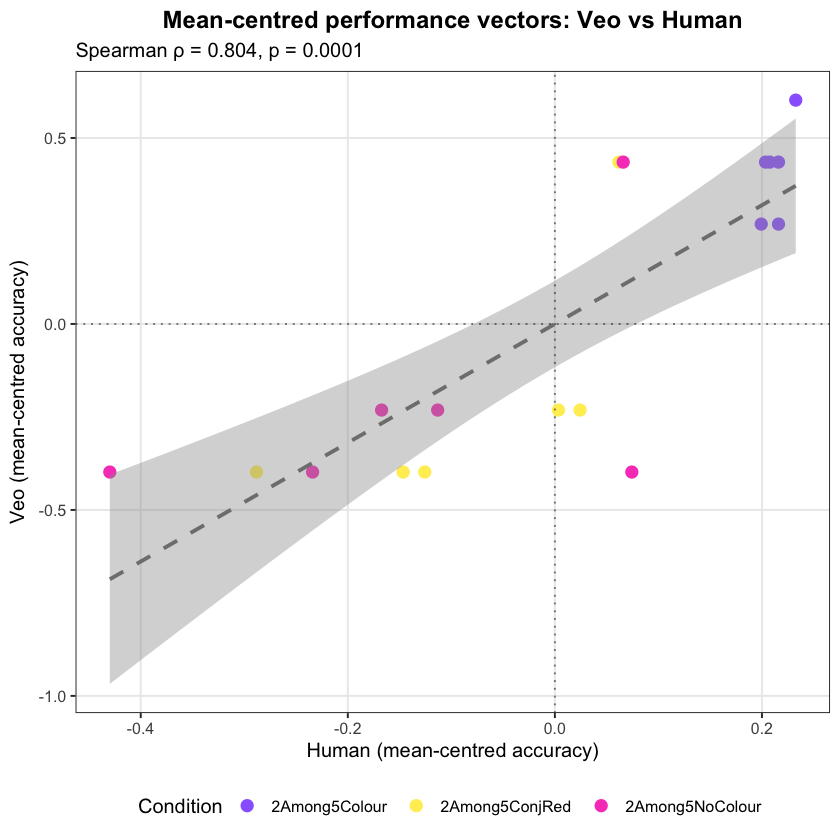

In [36]:
vecctors_wide = factor(vectors_wide$condition, labels =  condition_labels)
vectors_wide %>%
  ggplot(aes(x = Human, y = Veo, colour = condition)) +
  geom_point(size = 3) +
  geom_smooth(method = "lm", se = TRUE, 
              colour = "grey50", linetype = "dashed") +
  geom_hline(yintercept = 0, linetype = "dotted", alpha = 0.5) +
  geom_vline(xintercept = 0, linetype = "dotted", alpha = 0.5) +
  scale_colour_manual(values = c(
    "2Among5Colour"   = "#9B69FF",
    "2Among5ConjRed"  = "#FFED61",
    "2Among5NoColour" = "#F84AC1"
  )) +
  labs(
    title    = "Mean-centred performance vectors: Veo vs Human",
    subtitle = sprintf("Spearman ρ = %.3f, p = %.4f", 
                       spearman_res$estimate, 
                       spearman_res$p.value),
    x        = "Human (mean-centred accuracy)",
    y        = "Veo (mean-centred accuracy)",
    colour   = "Condition"
  ) +
  theme_bw(base_size = 12) +
  theme(
    legend.position  = "bottom",
    legend.box       = "vertical",
    panel.grid.minor = element_blank(),
    plot.title       = element_text(face = "bold", hjust = 0.5),
    axis.text.x      = element_text(lineheight = 1.3)
  )

Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”


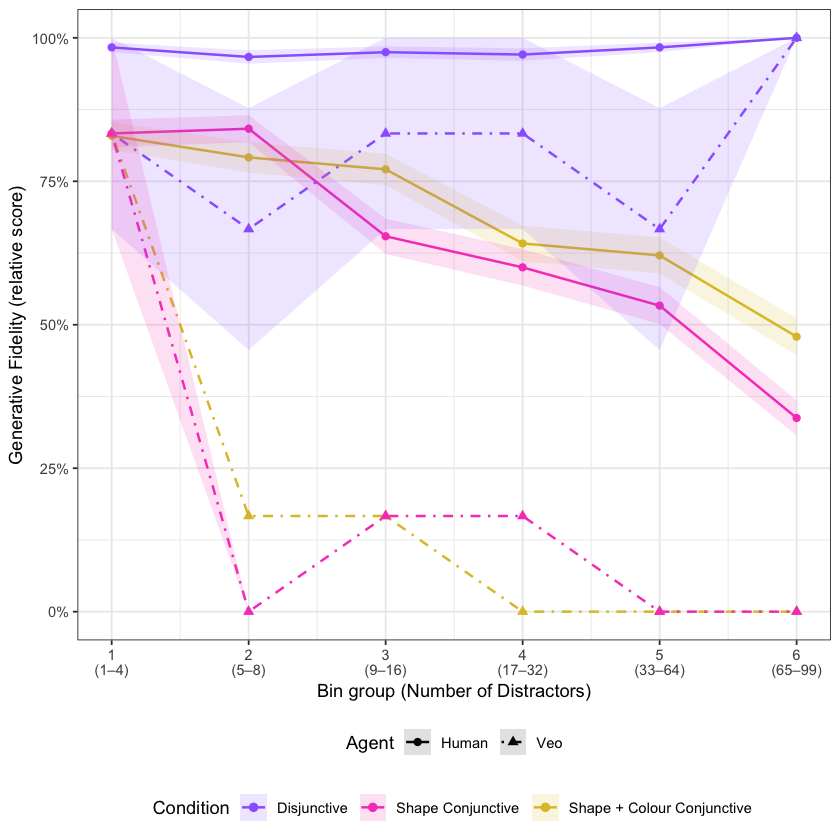

In [37]:
grouped_humanVeo <- humanAndVeo %>%
  group_by(agent, condition, bin_group) %>%
  summarise(
    generative_success = mean(success, na.rm = TRUE),
    std_success        = sd(success, na.rm = TRUE),
    n                  = n(),
    se                 = std_success / sqrt(n),
    .groups = "drop"
  )

ggplot(grouped_humanVeo, aes(
  x      = bin_group,
  y      = generative_success,
  colour = condition,
  linetype = agent,
  shape    = agent,
  group  = interaction(condition, agent)
)) +
  geom_line(linewidth = 0.7) +
  geom_point(size = 2) +
  geom_ribbon(aes(
    ymin  = generative_success - se,
    ymax  = generative_success + se,
    fill  = condition,
    group = interaction(condition, agent)
  ),
  alpha   = 0.15,
  colour  = NA
  ) +
  scale_y_continuous(
    labels = scales::percent_format(accuracy = 1),
    limits = c(0, 1)
  ) +
  scale_x_continuous(
    breaks = 1:6,
    labels = bin_labels
  ) +
  scale_colour_manual(
    values = colours,
    breaks = names(condition_labels),
    labels = condition_labels
  ) +
  scale_fill_manual(
    values = colours,
    breaks = names(condition_labels),
    labels = condition_labels
  ) +
  scale_linetype_manual(values = c(
    "Human" = "solid",
    "Veo"   = "dotdash"
  )) +
  scale_shape_manual(values = c(
    "Human" = 16,
    "Veo"   = 17
  )) +
  labs(
    x        = "Bin group (Number of Distractors)",
    y        = "Generative Fidelity (relative score)",
    colour   = "Condition",
    fill     = "Condition",
    linetype = "Agent",
    shape    = "Agent"
  ) +
  theme_bw() +
  theme(
    legend.position = "bottom",
    legend.box      = "vertical"
  )


# Hypothesis 3

### fisher test

In [21]:
# Check expected cell counts
expected <- chisq.test(error_ct)$expected
cat(sprintf("\nMinimum expected count: %.2f\n", min(expected)))

# Choose test accordingly
if (min(expected) >= 5) {
  cat("Using Pearson chi-square\n")
  print(chisq.test(error_ct))
} else {
  cat("Using Fisher-Freeman-Halton exact test\n")
  print(fisher.test(error_ct, simulate.p.value = TRUE, B = 10000))
}

ERROR: Error: object 'error_ct' not found


### load data

In [40]:
err_cols <- grep("^err_", names(fulldataAS), value = TRUE)
## prep data for fidelity score analysis
n_possible <- length(err_cols)
print(colnames(fulldataAS))
Fidelity_Subset = fulldataAS  %>% select(success, video_filename, fidelity_score_total, condition, bin_group) %>% mutate(fidelity_relative = fidelity_score_total/n_possible)
Fidelity_Subset$bin_group <- as.integer(Fidelity_Subset$bin_group)
table(Fidelity_Subset$condition, Fidelity_Subset$bin_group)
head(Fidelity_Subset)
Fidelity_Plot = Fidelity_Subset %>%
  group_by(condition, bin_group) %>%
  summarise(
    mean_fidelity = mean(fidelity_relative, na.rm = TRUE),
    sd_fidelity   = sd(fidelity_relative, na.rm = TRUE),
    n             = n(),
    se_fidelity   = sd_fidelity / sqrt(n),
    .groups = "drop"
  )
head(Fidelity_Plot)

 [1] "video_filename"          "condition"              
 [3] "bin_x"                   "source_image"           
 [5] "status"                  "image_condition"        
 [7] "shape_type"              "target"                 
 [9] "center_x"                "center_y"               
[11] "size"                    "color"                  
[13] "quadrant"                "row"                    
[15] "column"                  "num_distractors"        
[17] "num_images"              "distractor_color"       
[19] "color_bin_index"         "rotation_angle"         
[21] "bin_group"               "trial_index"            
[23] "condition.1"             "bin_y"                  
[25] "sample"                  "success"                
[27] "failure_type"            "err_no_distractors"     
[29] "err_no_target"           "err_wrong_manip"        
[31] "err_new_target_id"       "err_new_target_unid"    
[33] "err_extra_distractors"   "err_font_change"        
[35] "err_rotation"            

                 
                  1 2 3 4 5 6
  2Among5Colour   6 6 6 6 6 6
  2Among5ConjRed  6 6 6 6 6 6
  2Among5NoColour 6 6 6 6 6 6

,success,video_filename,fidelity_score_total,condition,bin_group,fidelity_relative
,<int>,<fct>,<int>,<fct>,<int>,<dbl>
1,0,2Among5Colour_Bin3_Sample6.mp4,7,2Among5Colour,3,0.4117647
2,1,2Among5Colour_Bin4_Sample2.mp4,5,2Among5Colour,4,0.2941176
3,1,2Among5Colour_Bin3_Sample3.mp4,4,2Among5Colour,3,0.2352941
4,1,2Among5Colour_Bin5_Sample5.mp4,6,2Among5Colour,5,0.3529412
5,1,2Among5Colour_Bin6_Sample2.mp4,4,2Among5Colour,6,0.2352941
6,1,2Among5Colour_Bin1_Sample1.mp4,6,2Among5Colour,1,0.3529412


condition,bin_group,mean_fidelity,sd_fidelity,n,se_fidelity
<fct>,<int>,<dbl>,<dbl>,<int>,<dbl>
2Among5Colour,1,0.2647059,0.09665692,6,0.03946002
2Among5Colour,2,0.3333333,0.07123883,6,0.02908313
2Among5Colour,3,0.3039216,0.10793223,6,0.04406315
2Among5Colour,4,0.2156863,0.08856149,6,0.03615508
2Among5Colour,5,0.2745098,0.04802921,6,0.01960784
2Among5Colour,6,0.2254902,0.11416413,6,0.04660731


In [41]:
fidelity_counts_condition = Fidelity_Subset %>%
  group_by(condition) %>%
  summarise(
    mean_fidelity = mean(fidelity_relative, na.rm = TRUE),
    sd_fidelity   = sd(fidelity_relative, na.rm = TRUE),
    n             = n(),
    se_fidelity   = sd_fidelity / sqrt(n),
    CI_lower      = mean_fidelity - 1.96 * se_fidelity,
    CI_upper      = mean_fidelity + 1.96 *  se_fidelity,
    .groups = "drop"
  )
  print(fidelity_counts_condition)
fidelity_counts_bin = Fidelity_Subset %>%
  group_by(bin_group) %>%   
  summarise(
    mean_fidelity = mean(fidelity_relative, na.rm = TRUE),
    sd_fidelity   = sd(fidelity_relative, na.rm = TRUE),
    n             = n(),
    se_fidelity   = sd_fidelity / sqrt(n),
    CI_lower      = mean_fidelity - 1.96 * se_fidelity,
    CI_upper      = mean_fidelity + 1.96 *  se_fidelity,
    .groups = "drop"
  )
  print(fidelity_counts_bin)

error_summary <- fulldataAS %>%
  summarise(
    across(
      starts_with("err_"),
      ~ sum(.x == 1, na.rm = TRUE),
      .names = "{.col}"
    )
  ) %>%
  pivot_longer(
    cols = everything(),
    names_to = "error_type",
    values_to = "total_count"
  ) %>%
  mutate(
    prop = total_count / 108
  ) %>%
  arrange(desc(total_count))

print(error_summary)

# A tibble: 3 × 7
  condition       mean_fidelity sd_fidelity     n se_fidelity CI_lower CI_upper
  <fct>                   <dbl>       <dbl> <int>       <dbl>    <dbl>    <dbl>
1 2Among5Colour           0.270      0.0937    36      0.0156    0.239    0.300
2 2Among5ConjRed          0.315      0.120     36      0.0200    0.276    0.355
3 2Among5NoColour         0.302      0.123     36      0.0205    0.262    0.342
# A tibble: 6 × 7
  bin_group mean_fidelity sd_fidelity     n se_fidelity CI_lower CI_upper
      <int>         <dbl>       <dbl> <int>       <dbl>    <dbl>    <dbl>
1         1         0.278      0.122     18      0.0289    0.221    0.334
2         2         0.373      0.105     18      0.0247    0.324    0.421
3         3         0.314      0.118     18      0.0277    0.259    0.368
4         4         0.288      0.127     18      0.0300    0.229    0.346
5         5         0.261      0.0951    18      0.0224    0.217    0.305
6         6         0.261      0.0813    18   

### check assumptions


	Shapiro-Wilk normality test

data:  residuals(model_hypothesis3)
W = 0.99282, p-value = 0.8466



	studentized Breusch-Pagan test

data:  model_hypothesis3
BP = 10.257, df = 5, p-value = 0.06827


there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



,GVIF,Df,GVIF^(1/(2*Df))
condition,27.04,2,2.280351
bin_group,3.00,1,1.732051
condition:bin_group,37.44,2,2.473626


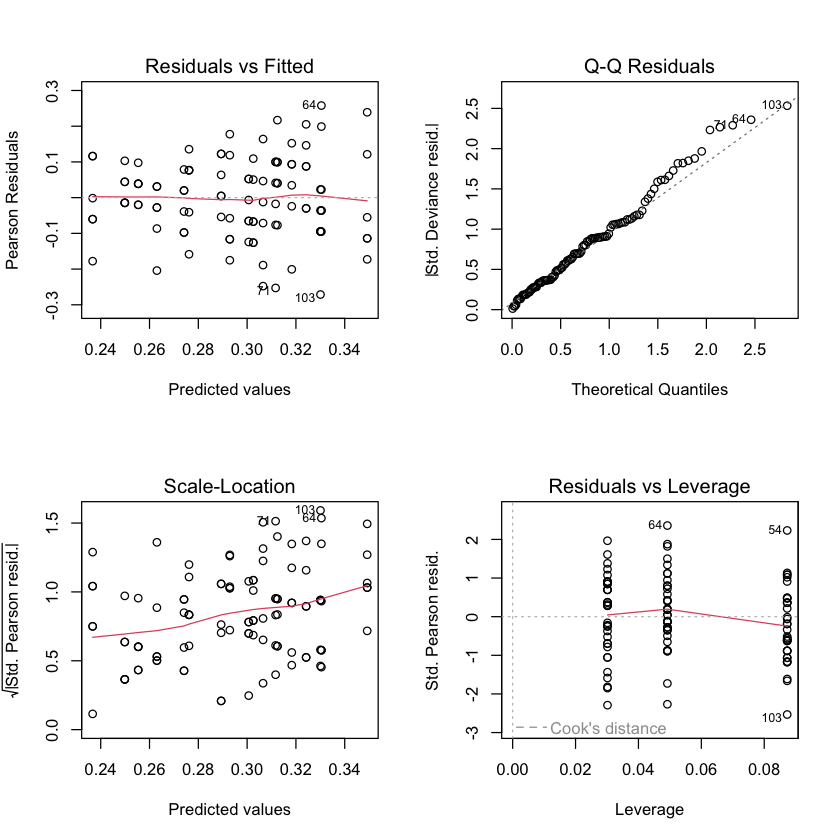

In [42]:
model_hypothesis3= glm(fidelity_relative ~ condition*bin_group, data = Fidelity_Subset)
#  Normality 
shapiro.test(residuals(model_hypothesis3)) # OK, not significant = H0 cannot be rejected (H0 being that residuals are normally distributed)
# Homoscedasticity
bptest(model_hypothesis3)  # Breusch-Pagan
#  Visual checks
par(mfrow = c(2,2)) # they all look ok 
plot(model_hypothesis3)
# Multicollinearity (for interaction terms) - OK ish condition and interaction are gvif > 10, adjusted for df is < sqrt(10) so likely OKish
vif(model_hypothesis3)

## modelling

In [43]:
summary(model_hypothesis3)


Call:
glm(formula = fidelity_relative ~ condition * bin_group, data = Fidelity_Subset)

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                         0.315686   0.042601   7.410 3.78e-11 ***
condition2Among5ConjRed             0.020261   0.060246   0.336    0.737    
condition2Among5NoColour            0.052288   0.060246   0.868    0.387    
bin_group                          -0.013165   0.010939  -1.204    0.232    
condition2Among5ConjRed:bin_group   0.007283   0.015470   0.471    0.639    
condition2Among5NoColour:bin_group -0.005602   0.015470  -0.362    0.718    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for gaussian family taken to be 0.01256406)

    Null deviance: 1.3803  on 107  degrees of freedom
Residual deviance: 1.2815  on 102  degrees of freedom
AIC: -158.39

Number of Fisher Scoring iterations: 2



	Shapiro-Wilk normality test

data:  residuals(drop_model_hypothesis3)
W = 0.9949, p-value = 0.9626



	studentized Breusch-Pagan test

data:  drop_model_hypothesis3
BP = 7.3698, df = 3, p-value = 0.061


,GVIF,Df,GVIF^(1/(2*Df))
condition,1,2,1
bin_group,1,1,1



Call:
glm(formula = fidelity_relative ~ condition + bin_group, data = Fidelity_Subset)

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)               0.313725   0.028760  10.909   <2e-16 ***
condition2Among5ConjRed   0.045752   0.026254   1.743   0.0843 .  
condition2Among5NoColour  0.032680   0.026254   1.245   0.2160    
bin_group                -0.012605   0.006276  -2.008   0.0472 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for gaussian family taken to be 0.01240673)

    Null deviance: 1.3803  on 107  degrees of freedom
Residual deviance: 1.2903  on 104  degrees of freedom
AIC: -161.65

Number of Fisher Scoring iterations: 2


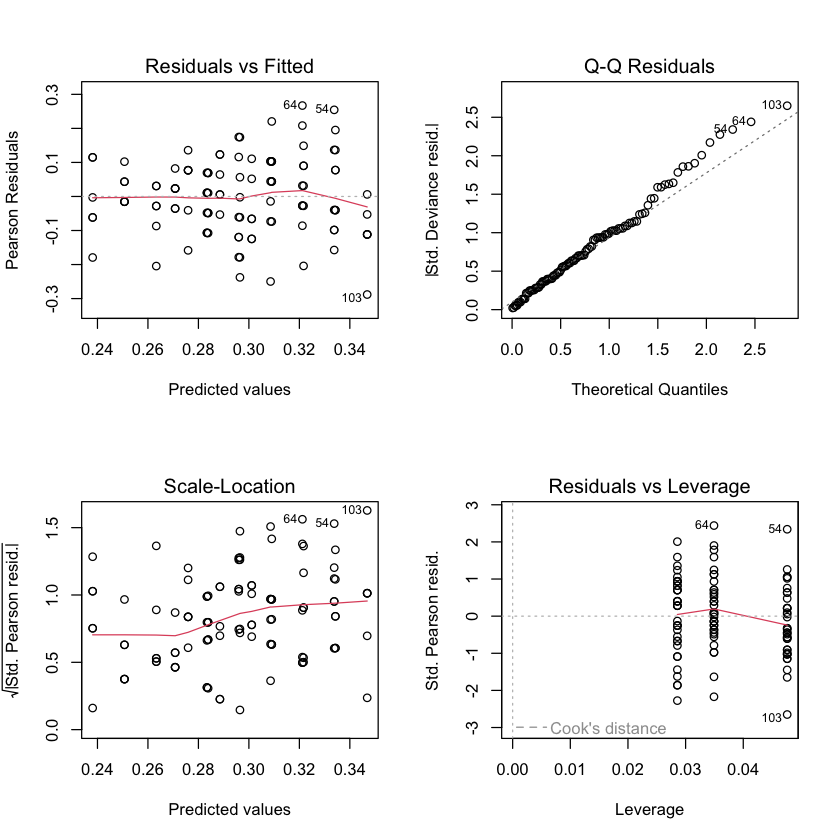

In [44]:
drop_model_hypothesis3= glm(fidelity_relative ~ condition + bin_group, data = Fidelity_Subset)
#  Normality 
shapiro.test(residuals(drop_model_hypothesis3)) # OK, not significant = H0 cannot be rejected (H0 being that residuals are normally distributed)
# Homoscedasticity
bptest(drop_model_hypothesis3)  # Breusch-Pagan
#  Visual checks
par(mfrow = c(2,2)) # they all look ok 
plot(drop_model_hypothesis3)
# Multicollinearity (for interaction terms) - OK ish condition and interaction are gvif > 10, adjusted for df is < sqrt(10) so likely OKish
vif(drop_model_hypothesis3)
summary(drop_model_hypothesis3)

## stay with old model AS AIC gets worse

### visualisation

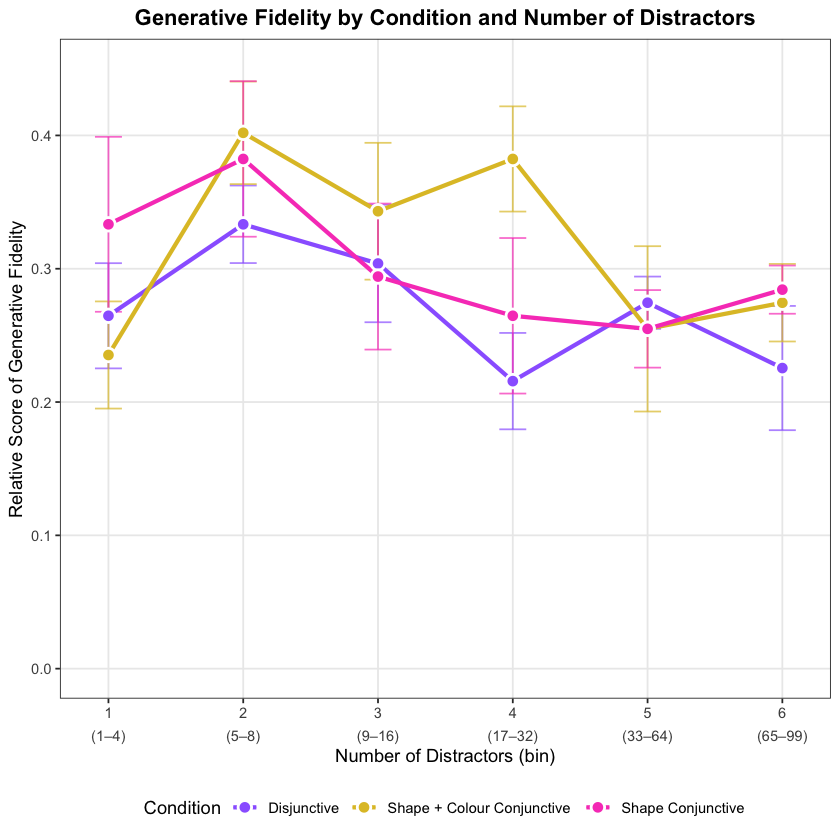

In [47]:
ggplot(Fidelity_Plot,
       aes(x      = bin_group,
           y      = mean_fidelity,
           colour = condition)) +
  geom_errorbar(aes(ymin = mean_fidelity - se_fidelity,
                    ymax = mean_fidelity + se_fidelity),
                width     = 0.2,
                linewidth = 0.5,
                alpha     = 0.7) +
  geom_line(linewidth = 1.2) +
  geom_point(size   = 3,
             shape  = 21,
             aes(fill = condition),
             colour = "white",
             stroke = 1.2) +
  scale_colour_manual(
    values = colours,
    labels = condition_labels
  ) +
  scale_fill_manual(
    values = colours,
    labels = condition_labels
  ) +
  scale_x_continuous(
    breaks = 1:6,
    labels = bin_labels
  ) +
  scale_y_continuous(limits = c(0,0.45)) +
  labs(x      = "Number of Distractors (bin)",
       y      = "Relative Score of Generative Fidelity",
       colour = "Condition",
       fill   = "Condition",
       title = "Generative Fidelity by Condition and Number of Distractors" ) +
  theme_minimal(base_size = 13) +
  theme_bw() +
  theme(
    legend.position  = "bottom",
    strip.text       = element_text(face = "bold", size = 12),
    panel.grid.minor = element_blank(),
    panel.spacing    = unit(1.5, "lines"),
    plot.title       = element_text(face = "bold", hjust = 0.5),
    axis.text.x      = element_text(lineheight = 1.3)
  )


### post hock test

In [ ]:
trends_H3 = emtrends(model_hypothesis3, specs = ~ condition, var = "bin_group")
summary(trends_H3, infer = c(TRUE, TRUE))
marginalmeans_H3 = emmeans(model_hypothesis3, specs= ~condition, var = "bin_group")
summary(marginalmeans_H3, infer = c(TRUE, TRUE))


,condition,bin_group.trend,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2Among5Colour,-0.021288515,0.01015738,102,-0.04143563,-0.0011414000,-2.095867,0.03856909
2,2Among5ConjRed,-0.008683473,0.01015738,102,-0.02883059,0.0114636421,-0.854893,0.39461392
3,2Among5NoColour,-0.020728291,0.01015738,102,-0.04087541,-0.0005811759,-2.040712,0.04386256


NOTE: Results may be misleading due to involvement in interactions



,condition,emmean,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2Among5Colour,0.2385621,0.01734703,102,0.2041543,0.2729698,13.75233,5.733860e-25
2,2Among5ConjRed,0.3022876,0.01734703,102,0.2678798,0.3366953,17.42590,2.400494e-32
3,2Among5NoColour,0.2810458,0.01734703,102,0.2466380,0.3154535,16.20138,5.744143e-30


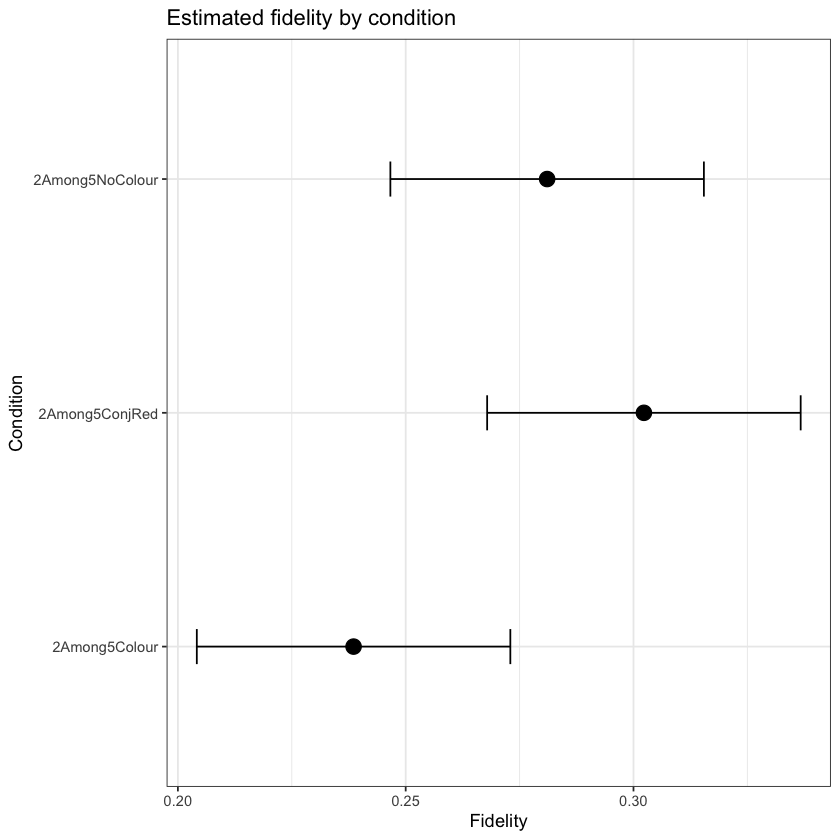

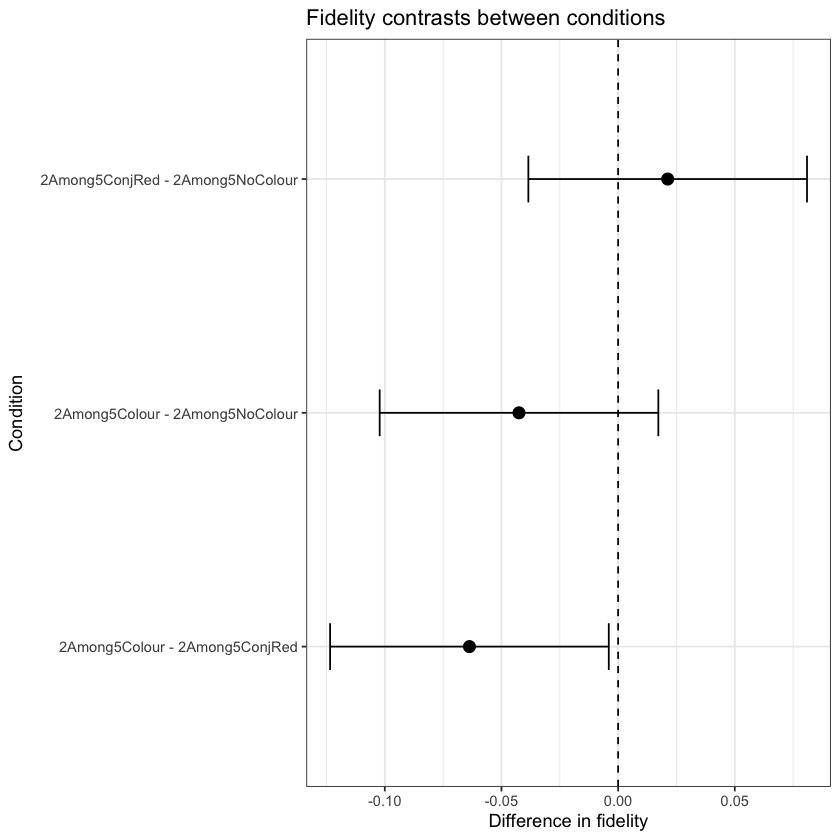

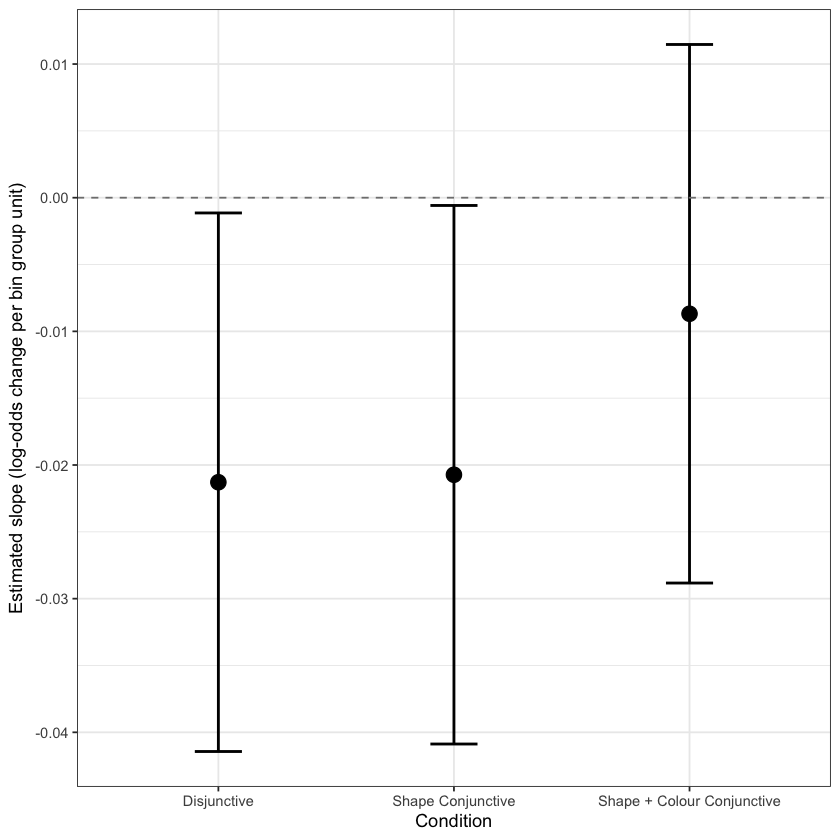

In [ ]:
## by condition
emm_h3_post1_plot = as.data.frame(emm_fidelity_condition)
ggplot(emm_h3_post1_plot, aes(x = condition, y = emmean)) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = lower.CL, ymax = upper.CL), width = 0.15) +
  theme_bw() +
  coord_flip() +  
  labs(title = "Estimated fidelity by condition", y = "Fidelity", x = "Condition")
## by contrasts
conditioncontrast_h3_post2_plot = summary(
  condition_fidelity_contrasts,
  infer = c(TRUE, TRUE)
) %>% as.data.frame()

ggplot(conditioncontrast_h3_post2_plot, aes(x = contrast, y = estimate)) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = lower.CL, ymax = upper.CL), width = 0.2) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  coord_flip() +
  theme_bw() +
  labs(y = "Difference in fidelity", x = "Condition", title = "Fidelity contrasts between conditions")

## Bin slope effects 
trends_H3_post3_plot = as.data.frame(summary(trends_H3, infer = c(TRUE, TRUE)))
# condition''bin_group.trend''SE''df''lower.CL''upper.CL''t.ratio''p.value'
trends_H3_post3_plot$condition <- factor(
  trends_H3_post3_plot$condition,
  labels = condition_labels,
  levels = names(condition_labels)
)
ggplot(trends_H3_post3_plot, aes(x = condition, y = bin_group.trend)) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = lower.CL, ymax = upper.CL),
                width = 0.2, linewidth = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey50") +
  theme_bw() +
  theme_bw() +
  labs(y = "Estimated slope (log-odds change per bin group unit)", x = "Condition")


### quali during marking suspicious 

In [ ]:
## prep data for fidelity score analysis
Fidelity_Expl = fulldata  %>% select(video_filename, err_circular_motion, err_extra_distractors, condition, bin_group)
Fidelity_Expl$bin_group <- as.factor(Fidelity_Expl$bin_group)
model_hypothesis3_expl= lm(err_circular_motion ~ condition*bin_group, data = Fidelity_Expl)

                 
                  1 2 3 4 5 6
  2Among5Colour   6 6 6 6 6 6
  2Among5ConjRed  6 6 6 6 6 6
  2Among5NoColour 6 6 6 6 6 6

# MLLM vs GVM 

### data import & processing

In [73]:
model = "gpt-4o" # paste here exactly 

data_MLLM_SC = read.csv(paste0("/Users/emmal/Desktop/CODE/VisualSearchLLM/results/2Among5-ShapeConj-Cells/",model,"_results_Cells.csv"), stringsAsFactors = T)
data_MLLM_D = read.csv(paste0("/Users/emmal/Desktop/CODE/VisualSearchLLM/results/2Among5-Dis-Cells/",model,"_results_Cells.csv"), stringsAsFactors = T)
data_MLLM_SCC = read.csv(paste0("/Users/emmal/Desktop/CODE/VisualSearchLLM/results/2Among5-ShapeColourConj-Cells/",model,"_results_Cells.csv"), stringsAsFactors = T)

data_names <- c("data_MLLM_SCC", "data_MLLM_D", "data_MLLM_SC")

for (name in data_names) {
  assign(
    name,
    get(name) %>%
      mutate(
        bin_group = case_when(
          num_distractors >= 1  & num_distractors <= 4  ~ 1,
          num_distractors >= 5  & num_distractors <= 8  ~ 2,
          num_distractors >= 9  & num_distractors <= 16 ~ 3,
          num_distractors >= 17 & num_distractors <= 32 ~ 4,
          num_distractors >= 33 & num_distractors <= 64 ~ 5,
          num_distractors >= 65 & num_distractors <= 99 ~ 6,
          TRUE ~ NA_integer_
        ),
        
        Condition = case_when(
          name == "data_MLLM_SCC" ~ "2Among5ConjRed",
          name == "data_MLLM_D"   ~ "2Among5Colour",
          name == "data_MLLM_SC"  ~ "2Among5NoColour",
          TRUE                    ~ NA_character_
        ),
        
        correct = ifelse(correct == "True", 1, 0)
      )
  )
} 

"for (name in data_names) {
  assign(
    name,
    get(name) %>%
      group_by(bin_group) %>%
      summarise(
        mean = mean(correct, na.rm = TRUE)
      )
  )
}"

"for (name in data_names) {
  print(name)
  print(get(name))
}"

MLLM_summary =  bind_rows(
  data_MLLM_SCC %>% mutate(condition = "2Among5ConjRed"),
  data_MLLM_D   %>% mutate(condition = "2Among5Colour"),
  data_MLLM_SC  %>% mutate(condition = "2Among5NoColour")
) %>%
  group_by(condition, bin_group) %>%
  summarise(
    mean_acc = mean(correct, na.rm = TRUE),
    n = sum(!is.na(correct)),
    se = sqrt(mean_acc * (1 - mean_acc) / n),
    .groups = "drop"
  )
table(MLLM_summary$mean_acc, MLLM_summary$condition)

[1] "for (name in data_names) {\n  assign(\n    name,\n    get(name) %>%\n      group_by(bin_group) %>%\n      summarise(\n        mean = mean(correct, na.rm = TRUE)\n      )\n  )\n}"

[1] "for (name in data_names) {\n  print(name)\n  print(get(name))\n}"

                   
                    2Among5Colour 2Among5ConjRed 2Among5NoColour
  0.29755125284738              0              1               0
  0.366390306122449             0              1               0
  0.413890457368718             0              0               1
  0.492192379762648             0              1               0
  0.584316225693338             0              0               1
  0.599747474747475             0              1               0
  0.643518518518519             0              1               0
  0.643564356435643             0              0               1
  0.701923076923077             0              1               0
  0.718614718614719             0              0               1
  0.748427672955975             0              0               1
  0.748756218905473             0              0               1
  0.758620689655172             1              0               0
  0.82258064516129              1              0               0
  0.8

### plotting

[1] "condition" "bin_group" "mean_acc"  "se"        "agent"

[1] "condition" "bin_group" "mean_acc"  "se"        "agent"

[1] "condition" "bin_group" "mean_acc"  "se"        "agent"

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


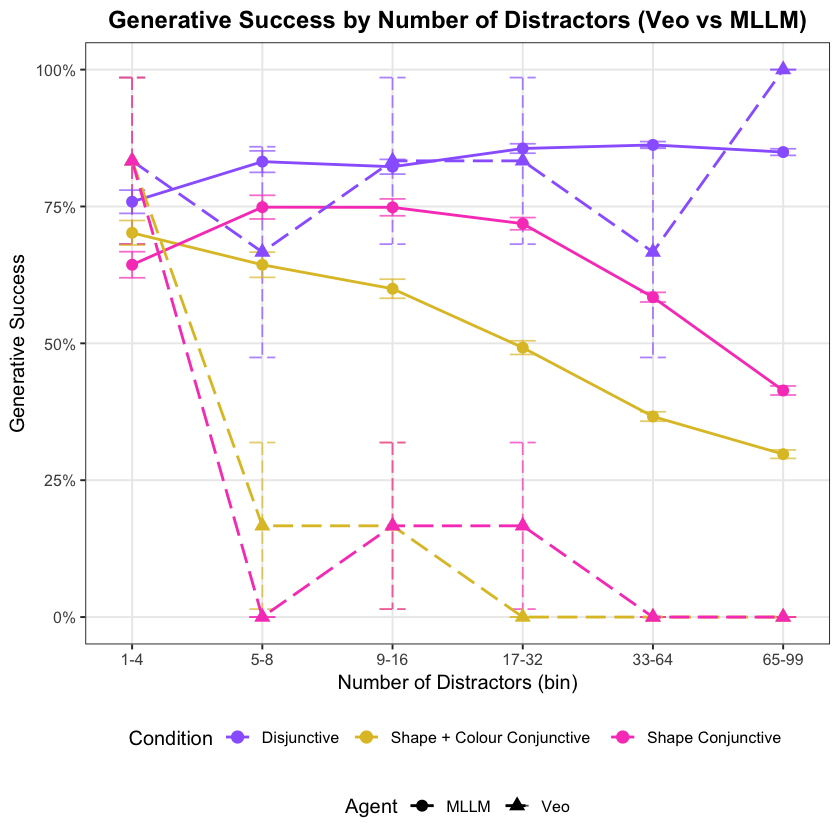

In [74]:
Veo_long <- combined_wide %>%
  select(condition, bin_group, mean_acc_veo, se_veo) %>%
  rename(
    mean_acc = mean_acc_veo,
    se = se_veo
  ) %>%
  mutate(agent = "Veo")

MLLM_long <- MLLM_summary %>%
  mutate(agent = "MLLM") %>%
  select(condition, bin_group, mean_acc, se, agent)

combined_long <- bind_rows(
  Veo_long,
  MLLM_long
)
colnames(Veo_long) 
colnames(combined_long)
colnames(MLLM_long)


ggplot(
  combined_long,
  aes(
    x = bin_group,
    y = mean_acc,
    colour = condition,
    linetype = agent,
    shape = agent,
    group = interaction(condition, agent)
  )
) +
  geom_errorbar(
    aes(
      ymin = mean_acc - se,
      ymax = mean_acc + se
    ),
    width = 0.2,
    linewidth = 0.5,
    alpha = 0.7
  ) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 3) +
  
  scale_colour_manual(
    values = colours,
    labels = condition_labels
  ) +
  
  scale_linetype_manual(
    name = "Agent",
    values = c(
      "MLLM" = "solid",
      "Veo" = "longdash"
    )
  ) +
  
  scale_shape_manual(
    name = "Agent",
    values = c(
      "MLLM" = 16,
      "Veo" = 17
    )
  ) +
  
  scale_x_continuous(
    breaks = 1:6,
    labels = c(
      "1-4", "5-8", "9-16",
      "17-32", "33-64", "65-99"
    )
  ) +
  
  scale_y_continuous(
    labels = scales::percent_format(),
    limits = c(0, 1)
  ) +
  
  labs(
    x = "Number of Distractors (bin)",
    y = "Generative Success",
    colour = "Condition",
    linetype = "Agent",
    title = "Generative Success by Number of Distractors (Veo vs MLLM)"
  ) +
  
  theme_bw(base_size = 12) +
  theme(
    legend.position = "bottom",
    legend.box = "vertical",
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.text.x = element_text(lineheight = 1.3)
  )
